In [1]:
# ------------------------------------------------------------
# 🚗 Chicago Traffic Speed Analysis — Python Version
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1️⃣ Load Dataset
# ------------------------------------------------------------
# Replace with your file path:
df = pd.read_excel("C:/Users/dunca/OneDrive/Desktop/ENMA 754/Project/Chicago_Traffic_Tracker_-_Congestion_Estimates_by_Segments_20251110.xlsx")

print(df.head())
print(df.info())


   SEGMENTID    STREET DIRECTION FROM_STREET    TO_STREET  LENGTH  \
0        875   LaSalle        NB   North Ave        Clark    0.12   
1         14      55th        WB      Austin       Mobile    0.50   
2         23   Pulaski        NB        95th         91st    0.50   
3        781  Peterson        EB     Western        Damen    0.50   
4         93   Pulaski        SB      Elston  Irving Park    0.40   

  STREET_HEADING      COMMENTS  START_LONGITUDE  START_LATITUDE  \
0              N           NaN       -87.632961       41.911159   
1              W           NaN       -87.772065       41.792680   
2              S  Outside City       -87.721158       41.720535   
3              W           NaN       -87.689694       41.990384   
4              N           NaN       -87.728041       41.959617   

   END_LONGITUDE  END_LATITUDE  CURRENT_SPEED           LAST_UPDATED  
0     -87.632772     41.913031             10  2025-11-10 19:50:31.0  
1     -87.779350     41.792486          

In [2]:
# ------------------------------------------------------------
# 2️⃣ Data Cleaning
# ------------------------------------------------------------

# Rename columns to Python-friendly names
try:  # Added try block to match the except block
    # Rename columns to Python-friendly names
    df = df.rename(columns={
            "SEGMENTID": "segment_id",
            "STREET": "street",
            "DIRECTION": "direction",
            "FROM_STREET": "from_street",
            "TO_STREET": "to_street",
            "LENGTH": "length_miles",
            "STREET_HEADING": "heading",
            "START_LONGITUDE": "start_lon",
            "START_LATITUDE": "start_lat",
            "END_LONGITUDE": "end_lon",
            "END_LATITUDE": "end_lat",
            "CURRENT_SPEED": "current_speed",
            "LAST_UPDATED": "timestamp"
        })
        
    # Make sure the rename worked before proceeding
    if "current_speed" in df.columns:
        # Convert speed to numeric
        df["current_speed"] = pd.to_numeric(df["current_speed"], errors="coerce")
            
        # Replace invalid speeds (-1) with NaN
        df.loc[df["current_speed"] < 0, "current_speed"] = np.nan
    else:
        # If the column is still named with the original name
        if "CURRENT_SPEED" in df.columns:
            df["CURRENT_SPEED"] = pd.to_numeric(df["CURRENT_SPEED"], errors="coerce")
            df.loc[df["CURRENT_SPEED"] < 0, "CURRENT_SPEED"] = np.nan
        
    # Parse timestamp (use the appropriate column name)
    timestamp_col = "timestamp" if "timestamp" in df.columns else "LAST_UPDATED"
    if timestamp_col in df.columns:
        df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")
        
except Exception as e:
    print(f"Error during data cleaning: {e}")

In [3]:
print(df.head)

<bound method NDFrame.head of       segment_id     street direction          from_street    to_street  \
0            875    LaSalle        NB            North Ave        Clark   
1             14       55th        WB               Austin       Mobile   
2             23    Pulaski        NB                 95th         91st   
3            781   Peterson        EB              Western        Damen   
4             93    Pulaski        SB               Elston  Irving Park   
...          ...        ...       ...                  ...          ...   
1252         243  Roosevelt        WB                Clark    Jefferson   
1253         979   Pershing        WB  Dr Martin L King Jr        State   
1254        1255    Halsted        SB            Roosevelt         16th   
1255         199      North        WB              Central       Austin   
1256        1235    Halsted        SB                 95th         99th   

      length_miles heading               COMMENTS  start_lon  start_l

['segment_id', 'street', 'direction', 'from_street', 'to_street', 'length_miles', 'heading', 'COMMENTS', 'start_lon', 'start_lat', 'end_lon', 'end_lat', 'current_speed', 'timestamp']


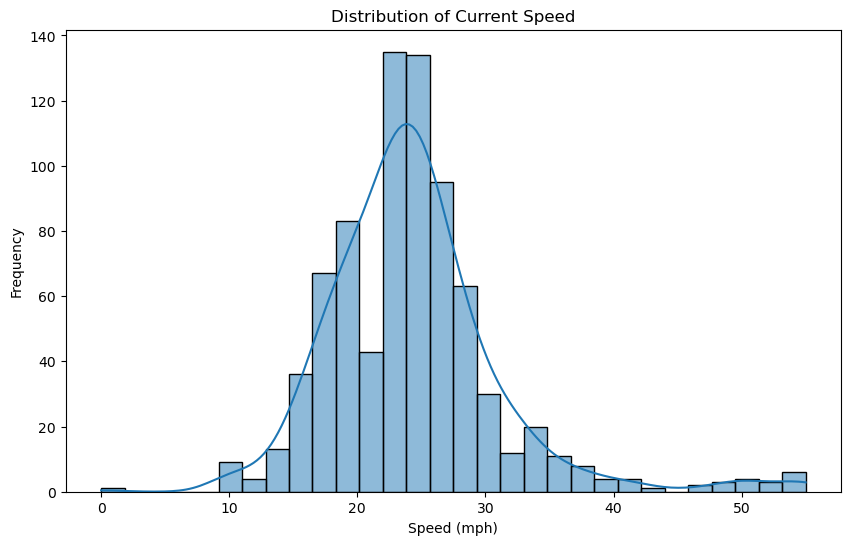

In [4]:
# ------------------------------------------------------------
# 3️⃣ Speed Analysis — Histogram + KDE
# ------------------------------------------------------------
print(df.columns.tolist())  # This will show all column names

plt.figure(figsize=(10, 6))
sns.histplot(df["current_speed"].dropna(), kde=True, bins=30)
plt.title("Distribution of Current Speed")
plt.xlabel("Speed (mph)")
plt.ylabel("Frequency")
plt.show()

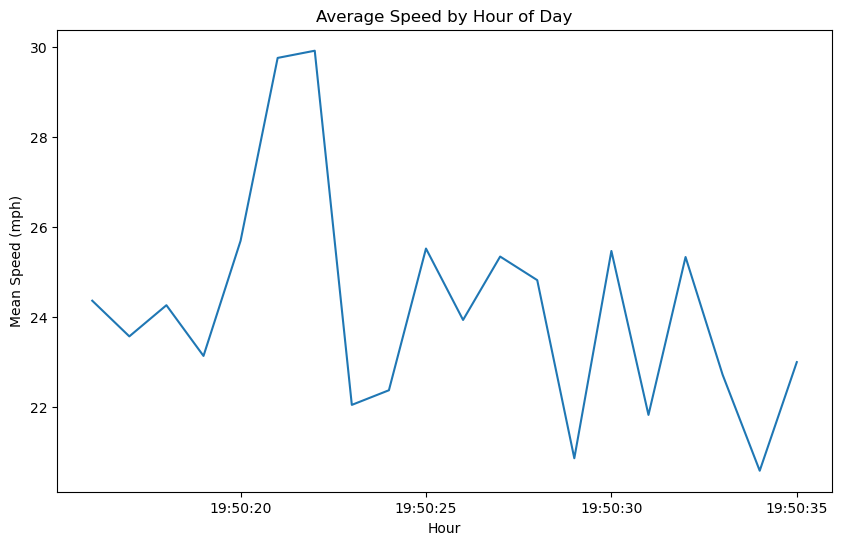

In [5]:
# ------------------------------------------------------------
# 4️⃣ Temporal Analysis
# ------------------------------------------------------------

# Extract hour from timestamp for time-based analysis
df["hour"] = df["timestamp"]
# Extract day name (Monday, Tuesday, etc.) from timestamp
df["day_of_week"] = df["timestamp"].dt.day_name()

# Calculate the average speed for each hour of the day
hourly_speed = df.groupby("hour")["current_speed"].mean()

# Create a line plot to visualize speed patterns throughout the day
plt.figure(figsize=(10,6))
sns.lineplot(x=hourly_speed.index, y=hourly_speed.values)
plt.title("Average Speed by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Mean Speed (mph)")
plt.show()

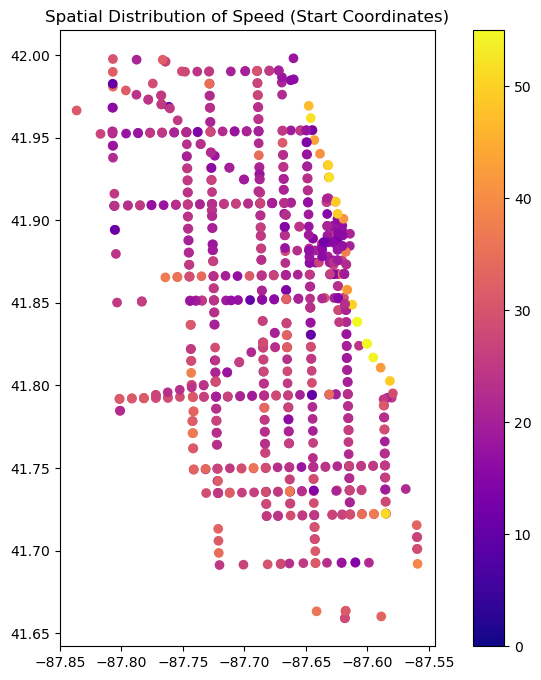

In [6]:
# ------------------------------------------------------------
# 5️⃣ Spatial Plot (if geopandas installed)
# ------------------------------------------------------------

try:
    import geopandas as gpd
    from shapely.geometry import Point

    df["geometry"] = df.apply(lambda row: Point(row["start_lon"], row["start_lat"]), axis=1)
    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

    gdf.plot(column="current_speed", cmap="plasma", legend=True, figsize=(10,8))
    plt.title("Spatial Distribution of Speed (Start Coordinates)")
    plt.show()

except ImportError:
    print("Install geopandas for spatial mapping: pip install geopandas")

In [7]:
# ------------------------------------------------------------
# 6️⃣ Predictive Modeling — Random Forest
# ------------------------------------------------------------

# Encode categorical variables
df_model = df[["current_speed", "hour", "day_of_week", "direction", "length_miles", "heading"]].dropna()

# Convert datetime columns to appropriate numeric representations
# If "hour" is a datetime, extract the hour component as an integer
if pd.api.types.is_datetime64_any_dtype(df_model["hour"]):
    df_model["hour"] = df_model["hour"].dt.hour  # Extract hour as integer

# Encode categorical variables
le_day = LabelEncoder()
df_model["day_of_week"] = le_day.fit_transform(df_model["day_of_week"])

le_dir = LabelEncoder()
df_model["direction"] = le_dir.fit_transform(df_model["direction"])

le_head = LabelEncoder()
df_model["heading"] = le_head.fit_transform(df_model["heading"])

# Ensure all columns are numeric
df_model = df_model.apply(pd.to_numeric, errors='coerce')
df_model = df_model.dropna()  # Remove any rows with NaN values after conversion

# Define features/target
X = df_model.drop("current_speed", axis=1)
y = df_model["current_speed"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("\n🔍 MODEL PERFORMANCE")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


🔍 MODEL PERFORMANCE
R²: 0.16075700958874684
RMSE: 6.76472953140041


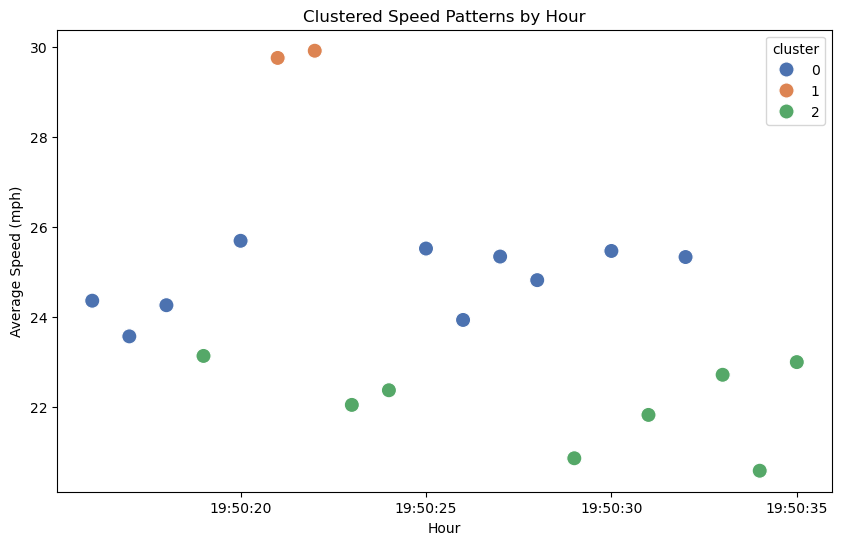

In [8]:
# ------------------------------------------------------------
# 7️⃣ Clustering Speed Behavior by Hour
# ------------------------------------------------------------

speed_hour = df.groupby("hour")["current_speed"].mean().reset_index()
speed_hour = speed_hour.dropna()

kmeans = KMeans(n_clusters=3, random_state=0)
speed_hour["cluster"] = kmeans.fit_predict(speed_hour[["current_speed"]])

plt.figure(figsize=(10,6))
sns.scatterplot(data=speed_hour, x="hour", y="current_speed", hue="cluster", palette="deep", s=120)
plt.title("Clustered Speed Patterns by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Speed (mph)")
plt.show()

# ------------------------------------------------------------
# END OF SCRIPT
# ------------------------------------------------------------


🔍 MODEL PERFORMANCE
R²: 0.32183169828553027
RMSE: 6.08100442195812


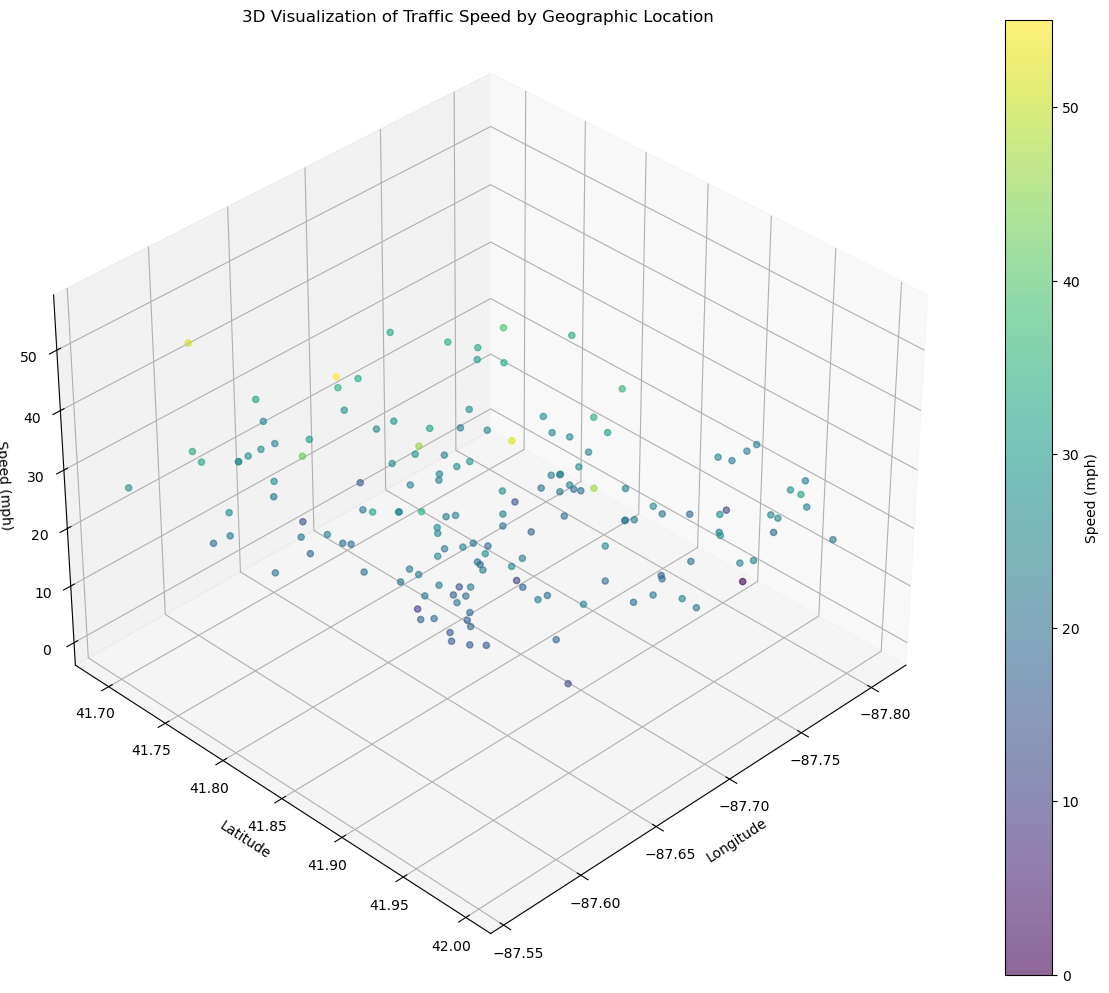

In [9]:
df_model = df[["current_speed", "start_lat", "start_lon", "direction", "length_miles", "heading"]].dropna()

# Encode categorical variables
le_dir = LabelEncoder()
df_model["direction"] = le_dir.fit_transform(df_model["direction"])

le_head = LabelEncoder()
df_model["heading"] = le_head.fit_transform(df_model["heading"])

# Ensure all columns are numeric
df_model = df_model.apply(pd.to_numeric, errors='coerce')
df_model = df_model.dropna()  # Remove any rows with NaN values after conversion

# Define features/target
X = df_model.drop("current_speed", axis=1)
y = df_model["current_speed"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("\n🔍 MODEL PERFORMANCE")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Create a 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the test data points
scatter = ax.scatter(X_test['start_lon'], X_test['start_lat'], y_test, 
                    c=y_test, cmap='viridis', label='Actual Speed', alpha=0.6)

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Speed (mph)')

# Set labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Speed (mph)')
ax.set_title('3D Visualization of Traffic Speed by Geographic Location')

# Add grid for better visualization
ax.grid(True)

# Adjust the viewing angle for better perspective
ax.view_init(elev=35, azim=45)

plt.tight_layout()
plt.show()


🔍 MODEL PERFORMANCE
R²: 0.32183169828553027
RMSE: 6.08100442195812


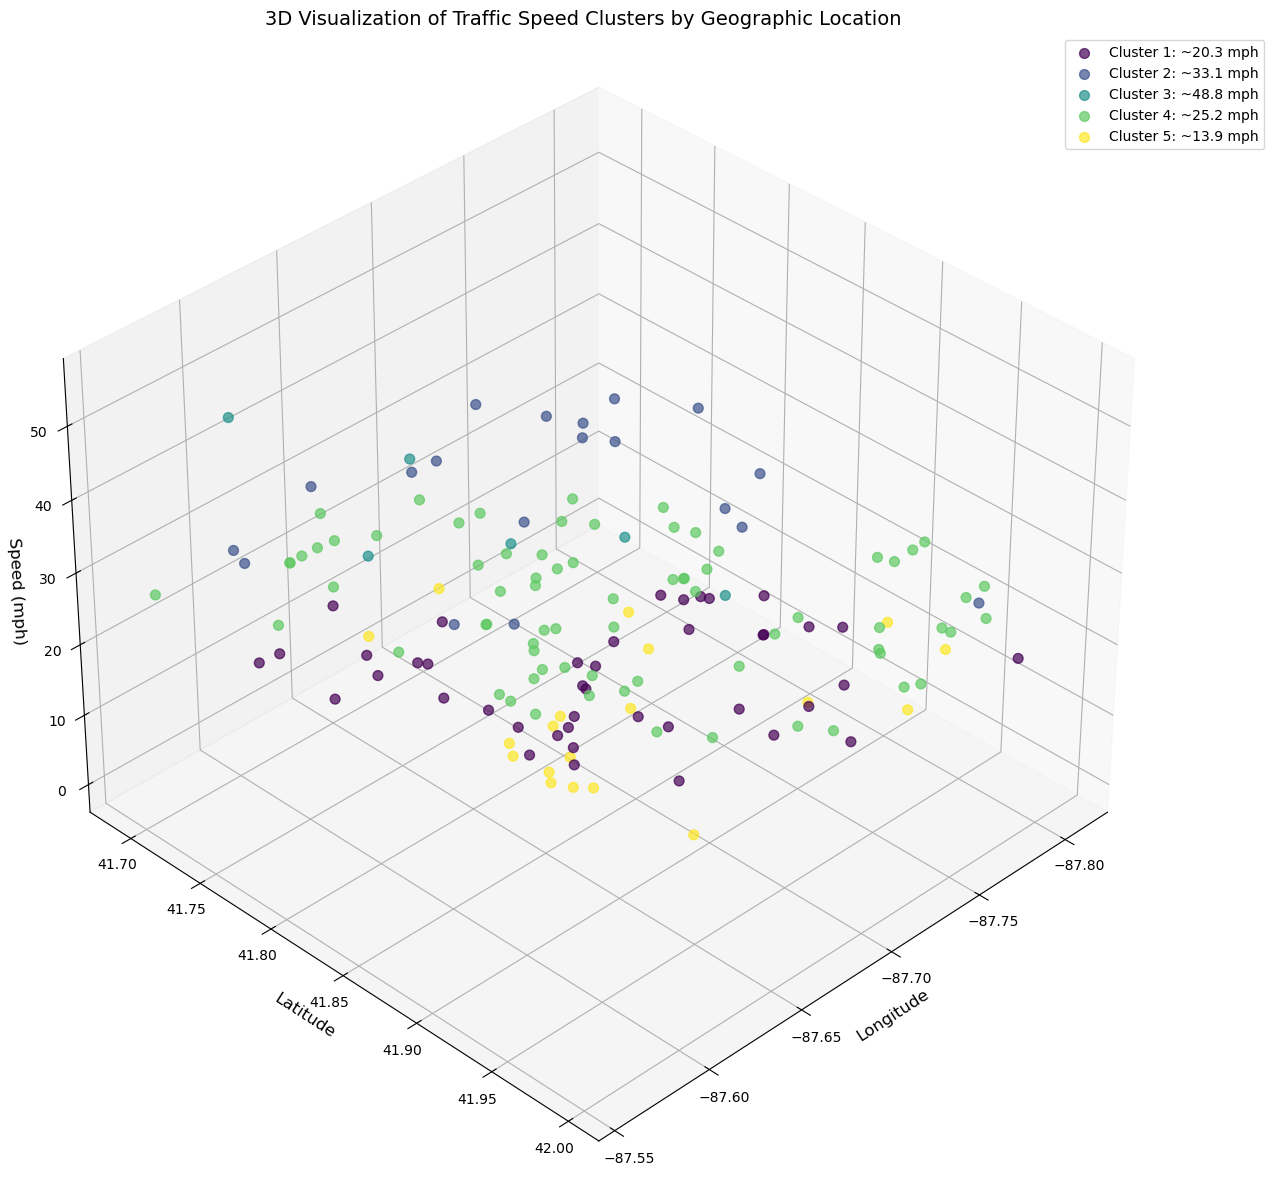

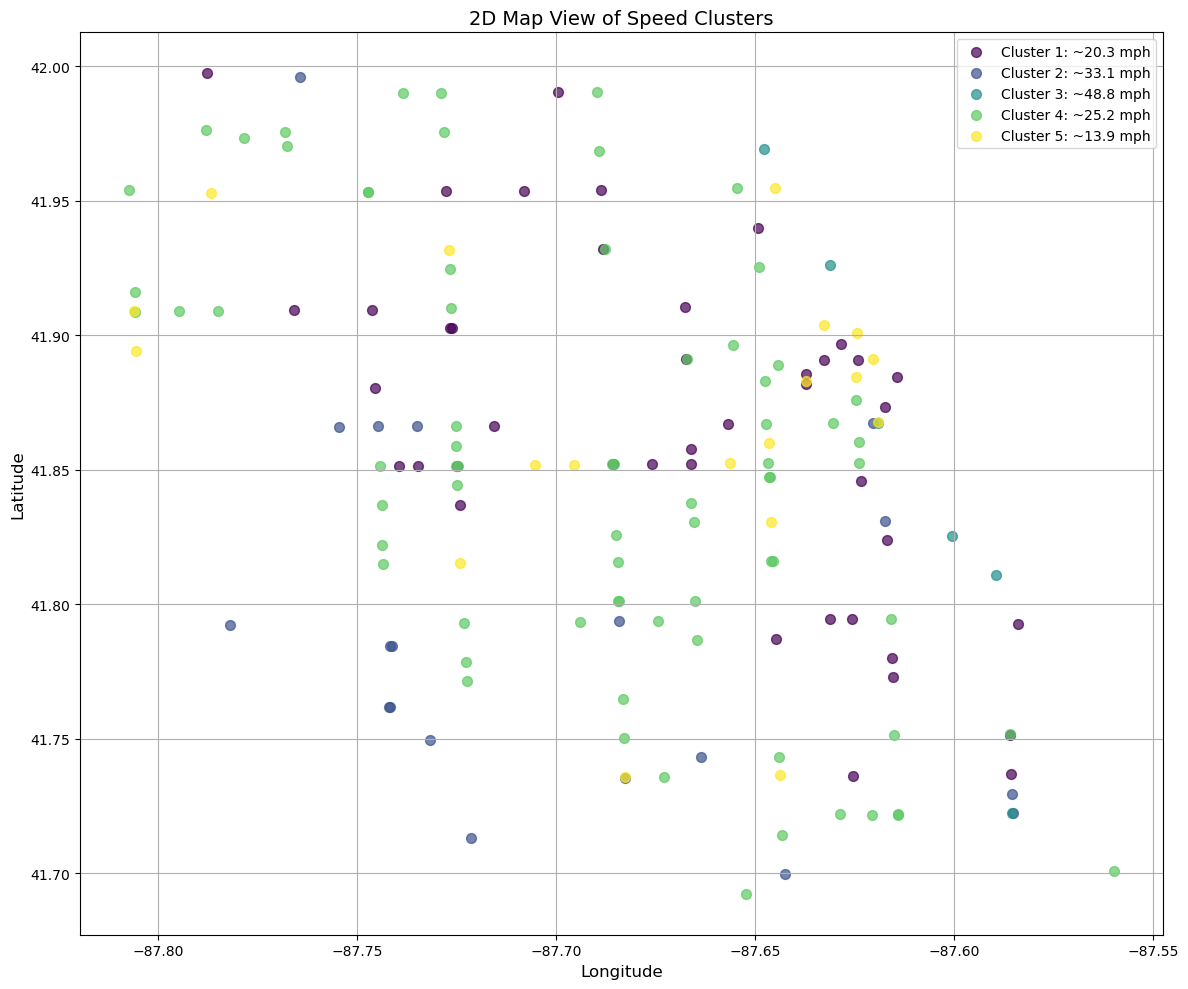

In [10]:
from matplotlib.colors import ListedColormap
df_model = df[["current_speed", "start_lat", "start_lon", "direction", "length_miles", "heading"]].dropna()

# Encode categorical variables
le_dir = LabelEncoder()
df_model["direction"] = le_dir.fit_transform(df_model["direction"])

le_head = LabelEncoder()
df_model["heading"] = le_head.fit_transform(df_model["heading"])

# Ensure all columns are numeric
df_model = df_model.apply(pd.to_numeric, errors='coerce')
df_model = df_model.dropna()

# Define features/target
X = df_model.drop("current_speed", axis=1)
y = df_model["current_speed"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("\n🔍 MODEL PERFORMANCE")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Create speed clusters using KMeans
# Reshape y_test to a column vector for KMeans
y_test_reshaped = y_test.values.reshape(-1, 1)

# Define number of clusters (speed ranges)
n_clusters = 5  # You can adjust this number based on your data

# Apply KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(y_test_reshaped)

# Get cluster centers for labeling
cluster_centers = kmeans.cluster_centers_.flatten()
sorted_indices = np.argsort(cluster_centers)
cluster_labels = {i: f"Cluster {i+1}: ~{cluster_centers[i]:.1f} mph" for i in range(n_clusters)}

# Create a 3D plot
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Define a colormap for the clusters
colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))
cmap = ListedColormap(colors)

# Plot each cluster with a different color
for cluster_id in range(n_clusters):
    # Get indices for this cluster
    cluster_indices = np.where(clusters == cluster_id)[0]
    
    # Plot points in this cluster
    ax.scatter(
        X_test.iloc[cluster_indices]['start_lon'], 
        X_test.iloc[cluster_indices]['start_lat'], 
        y_test.iloc[cluster_indices],
        c=[colors[cluster_id]],
        label=cluster_labels[cluster_id],
        s=50,
        alpha=0.7
    )

# Set labels
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_zlabel('Speed (mph)', fontsize=12)
ax.set_title('3D Visualization of Traffic Speed Clusters by Geographic Location', fontsize=14)

# Add grid for better visualization
ax.grid(True)

# Add a legend
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1))

# Adjust the viewing angle for better perspective
ax.view_init(elev=35, azim=45)

plt.tight_layout()
plt.show()

# Optional: Create a 2D map view of the clusters
plt.figure(figsize=(12, 10))
for cluster_id in range(n_clusters):
    cluster_indices = np.where(clusters == cluster_id)[0]
    plt.scatter(
        X_test.iloc[cluster_indices]['start_lon'], 
        X_test.iloc[cluster_indices]['start_lat'],
        c=[colors[cluster_id]],
        label=cluster_labels[cluster_id],
        alpha=0.7,
        s=50
    )

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('2D Map View of Speed Clusters', fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

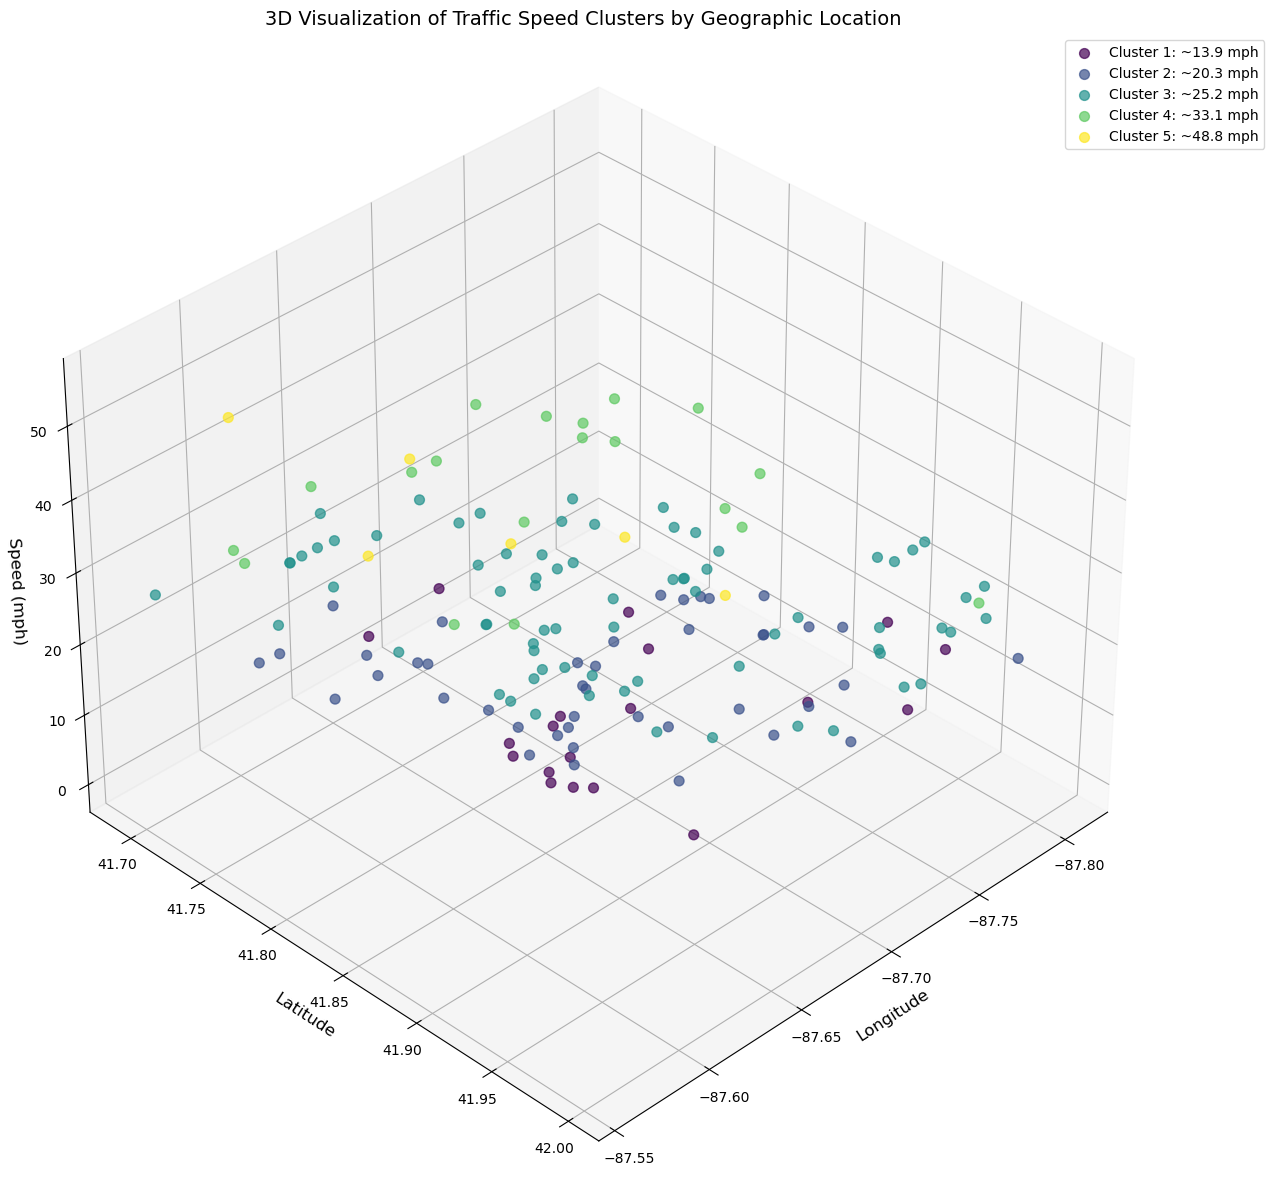

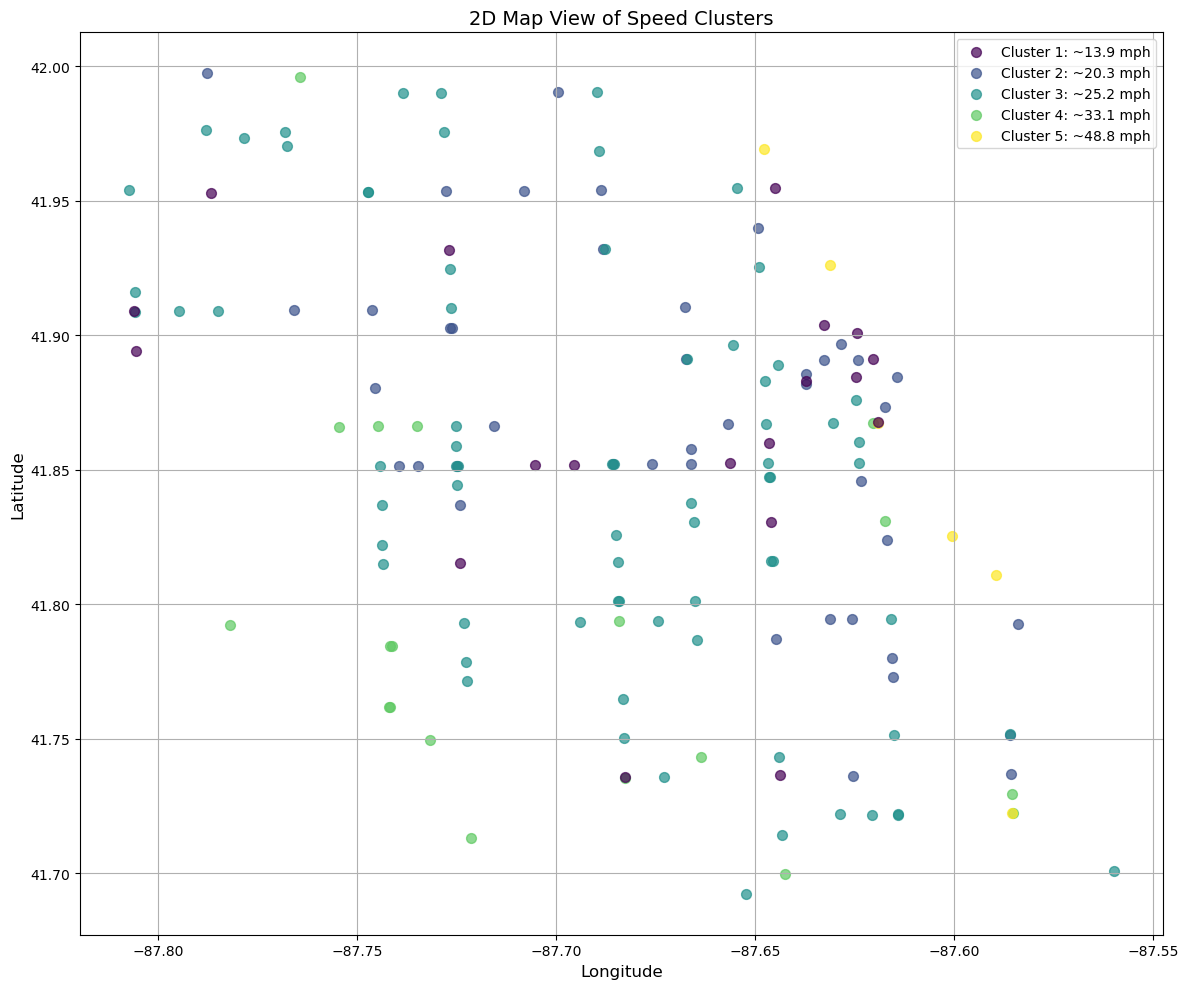

In [11]:
# Create speed clusters using KMeans
# Reshape y_test to a column vector for KMeans
y_test_reshaped = y_test.values.reshape(-1, 1)

# Define number of clusters (speed ranges)
n_clusters = 5  # You can adjust this number based on your data

# Apply KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(y_test_reshaped)

# Get cluster centers and sort them
cluster_centers = kmeans.cluster_centers_.flatten()
sorted_indices = np.argsort(cluster_centers)
sorted_centers = cluster_centers[sorted_indices]

# Create mapping from original cluster ID to sorted position
cluster_rank = {original_id: rank for rank, original_id in enumerate(sorted_indices)}

# Create labels based on sorted speeds
cluster_labels = {i: f"Cluster {sorted_indices.tolist().index(i)+1}: ~{cluster_centers[i]:.1f} mph" 
                 for i in range(n_clusters)}

# Define a colormap with colors ordered by speed
colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))
sorted_colors = colors[sorted_indices]

# Create a 3D plot
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster with a color corresponding to its speed rank
for cluster_id in range(n_clusters):
    # Get indices for this cluster
    cluster_indices = np.where(clusters == cluster_id)[0]
    
    # Use the rank to determine color (slower speeds get "cooler" colors)
    color_idx = cluster_rank[cluster_id]
    
    # Plot points in this cluster
    scatter = ax.scatter(
        X_test.iloc[cluster_indices]['start_lon'], 
        X_test.iloc[cluster_indices]['start_lat'], 
        y_test.iloc[cluster_indices],
        c=[colors[color_idx]],
        label=cluster_labels[cluster_id],
        s=50,
        alpha=0.7
    )

# Set labels
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_zlabel('Speed (mph)', fontsize=12)
ax.set_title('3D Visualization of Traffic Speed Clusters by Geographic Location', fontsize=14)

# Add grid for better visualization
ax.grid(True)

# Sort the legend by speed
handles, labels = ax.get_legend_handles_labels()
sorted_legend = sorted(zip(handles, labels), 
                      key=lambda x: float(x[1].split("~")[1].split(" ")[0]))
sorted_handles, sorted_labels = zip(*sorted_legend)

# Add a sorted legend
ax.legend(sorted_handles, sorted_labels, loc='upper right', bbox_to_anchor=(1.1, 1))

# Adjust the viewing angle for better perspective
ax.view_init(elev=35, azim=45)

plt.tight_layout()
plt.show()

# 2D map view with ordered colors and legend
plt.figure(figsize=(12, 10))
for cluster_id in range(n_clusters):
    cluster_indices = np.where(clusters == cluster_id)[0]
    color_idx = cluster_rank[cluster_id]
    plt.scatter(
        X_test.iloc[cluster_indices]['start_lon'], 
        X_test.iloc[cluster_indices]['start_lat'],
        c=[colors[color_idx]],
        label=cluster_labels[cluster_id],
        alpha=0.7,
        s=50
    )

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('2D Map View of Speed Clusters', fontsize=14)
plt.grid(True)

# Sort the legend by speed for 2D plot as well
handles, labels = plt.gca().get_legend_handles_labels()
sorted_legend = sorted(zip(handles, labels), 
                      key=lambda x: float(x[1].split("~")[1].split(" ")[0]))
sorted_handles, sorted_labels = zip(*sorted_legend)
plt.legend(sorted_handles, sorted_labels)

plt.tight_layout()
plt.show()